# Примеры запросов при работе с базой данных **Chinook**

##  Подключаем необходимые модули

In [2]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


In [3]:
db_path = Path(Path.cwd().parent) / "db/chinook.db"
conn = sqlite3.connect(db_path)

##  Выбрать все записи из таблицы `customer`
Запрос `SELECT * FROM customer LIMIT 5;` извлекает все столбцы из таблицы `customer` и возвращает первые 5 строк данных — остальные записи игнорируются.

In [4]:
sql = "SELECT * FROM customer LIMIT 5;"
data = pd.read_sql_query(sql, conn)
data

,CustomerId,FirstName,LastName,Company,Address,City,State,Country,PostalCode,Phone,Fax,Email,SupportRepId
0,1,Luís,Gonçalves,Embraer - Empresa Brasileira de Aeronáutica S.A.,"Av. Brigadeiro Faria Lima, 2170",São José dos Campos,SP,Brazil,12227-000,+55 (12) 3923-5555,+55 (12) 3923-5566,luisg@embraer.com.br,3
1,2,Leonie,Köhler,NaN,Theodor-Heuss-Straße 34,Stuttgart,NaN,Germany,70174,+49 0711 2842222,NaN,leonekohler@surfeu.de,5
2,3,François,Tremblay,NaN,1498 rue Bélanger,Montréal,QC,Canada,H2G 1A7,+1 (514) 721-4711,NaN,ftremblay@gmail.com,3
3,4,Bjørn,Hansen,NaN,Ullevålsveien 14,Oslo,NaN,Norway,0171,+47 22 44 22 22,NaN,bjorn.hansen@yahoo.no,4
4,5,František,Wichterlová,JetBrains s.r.o.,Klanova 9/506,Prague,NaN,Czech Republic,14700,+420 2 4172 5555,+420 2 4172 5555,frantisekw@jetbrains.com,4


##  Выбрать все записи из таблицы `customer` по определенным столбцам
Запрос `SELECT FirstName, LastName, Country FROM customer LIMIT 5;` извлекает из таблицы `customer` только три указанных столбца (`FirstName`, `LastName` и `Country`) и возвращает первые 5 строк данных — все остальные строки игнорируются благодаря ограничению `LIMIT 5`.

In [5]:
sql = "SELECT FirstName, LastName, Country FROM customer LIMIT 5;"
data = pd.read_sql_query(sql, conn)
data

,FirstName,LastName,Country
0,Luís,Gonçalves,Brazil
1,Leonie,Köhler,Germany
2,François,Tremblay,Canada
3,Bjørn,Hansen,Norway
4,František,Wichterlová,Czech Republic


##  Посчитать кол-во клиентов каждой стране

Запрос `SELECT Country, COUNT(*) AS customer_count FROM customer GROUP BY Country ORDER BY customer_count DESC;` группирует записи из таблицы `customer` по столбцу `Country`, подсчитывает количество клиентов в каждой стране (`COUNT(*)` и присваивает результату псевдоним `customer_count`), а затем сортирует полученные данные по убыванию числа клиентов — так, что страна с наибольшим количеством клиентов оказывается первой в итоговом списке.

In [6]:
sql = """SELECT Country, Count(*) AS customer_count 
    FROM customer 
    GROUP BY Country 
    ORDER BY customer_count DESC;"""
data = pd.read_sql_query(sql, conn)
data.head(5)

,Country,customer_count
0,USA,13
1,Canada,8
2,France,5
3,Brazil,5
4,Germany,4


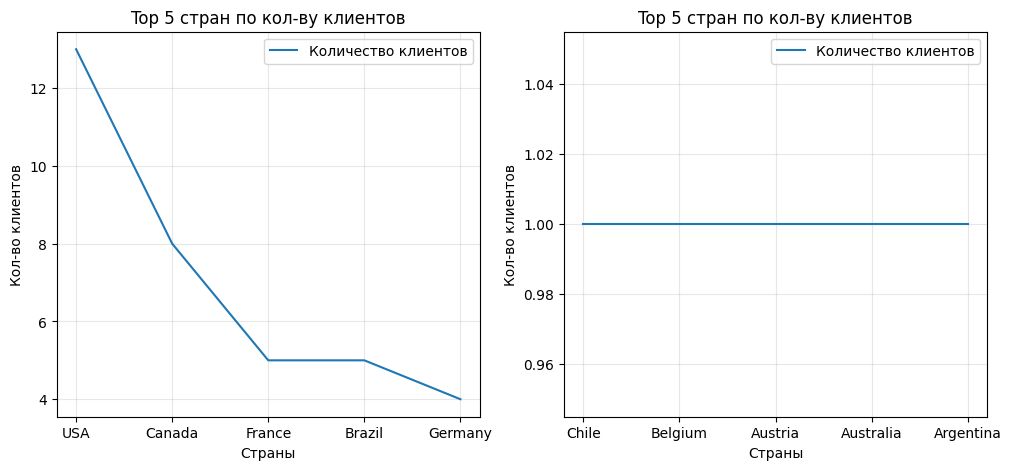

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(data["Country"].head(5), data["customer_count"].head(5), label="Количество клиентов")
ax1.set_ylabel("Кол-во клиентов")
ax1.set_xlabel("Страны")
ax1.set_title("Top 5 стран по кол-ву клиентов")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(data["Country"].tail(5), data["customer_count"].tail(5), label="Количество клиентов")
ax2.set_ylabel("Кол-во клиентов")
ax2.set_xlabel("Страны")
ax2.set_title("Top 5 стран по кол-ву клиентов")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.show()

##  Отчёт по продажам с разбивкой по клиентам и ответственным сотрудникам

Запрос объединяет данные из таблиц `customer`, `employee` и `invoice`, формирует полные имена клиента (`CustomerName`) и ответственного сотрудника (`EmployeeName`), подсчитывает количество счетов‑фактур (`invoices`) и суммирует их общую стоимость (`total`) для каждого клиента. Результаты группируются по идентификатору клиента и данным сотрудника, а затем сортируются по убыванию общей суммы (`total`).

In [17]:
sql = """SELECT 
	c.FirstName || ' ' || c.LastName AS CustomerName,
	e.FirstName || ' ' || e.LastName AS EmployeeName, 
	COUNT(i.InvoiceId) AS invoices, 
	SUM(i.Total) AS total
FROM customer c
LEFT JOIN employee e ON c.SupportRepId = e.EmployeeId
LEFT JOIN invoice i ON i.CustomerId  = c.CustomerId 
GROUP BY c.CustomerId, e.FirstName, e.LastName
ORDER BY total DESC;"""
data = pd.read_sql_query(sql, conn)
data.head()

,CustomerName,EmployeeName,invoices,total
0,Helena Holý,Steve Johnson,7,49.62
1,Richard Cunningham,Margaret Park,7,47.62
2,Luis Rojas,Steve Johnson,7,46.62
3,Ladislav Kovács,Jane Peacock,7,45.62
4,Hugh O'Reilly,Jane Peacock,7,45.62


## Отчёт по продажам менеджеров (количество и сумма счетов)

Запрос извлекает данные о сотрудниках (формирует полное имя через объединение полей `FirstName` и `LastName` в `EmployeeName`), подсчитывает количество счетов‑фактур (`Invoices`) и суммирует их общую стоимость (`Total`) для каждого сотрудника — с учётом клиентов, закреплённых за ним в качестве менеджера поддержки. Для этого выполняются соединения таблиц `Employee`, `Customer` (по полю `SupportRepId`) и `Invoice` (по `CustomerId`). Результаты группируются по идентификатору сотрудника (`e.EmployeeId`) и сортируются по убыванию суммарной стоимости счетов (`Total`). Функция `COALESCE` гарантирует замену возможных значений `NULL` на `0` в колонках `Invoices` и `Total`.

In [19]:
sql = """SELECT 
	e.FirstName || ' ' || e.LastName AS EmployeeName,
	COALESCE(COUNT(i.InvoiceId), 0) AS Invoices,
	COALESCE(SUM(i.Total), 0) AS Total
FROM Employee e
LEFT JOIN Customer c ON c.SupportRepId = e.EmployeeId
LEFT JOIN Invoice i ON i.CustomerId  = c.CustomerId 
GROUP BY e.EmployeeId 
ORDER BY total DESC;"""
data = pd.read_sql_query(sql, conn)
data

,EmployeeName,Invoices,Total
0,Jane Peacock,146,833.04
1,Margaret Park,140,775.40
2,Steve Johnson,126,720.16
3,Andrew Adams,0,0.00
4,Nancy Edwards,0,0.00
5,Michael Mitchell,0,0.00
6,Robert King,0,0.00
7,Laura Callahan,0,0.00


## Ежемесячная статистика по продажам всех продуктов

Этот запрос извлекает агрегированную информацию о счетах (инвойсах) по месяцам: группирует записи по месяцам (`STRFTIME('%Y-%m', i.InvoiceDate)`), подсчитывает количество уникальных клиентов (`COUNT(c.CustomerId)`), общее количество счетов (`COUNT(i.InvoiceId)`) и суммарную стоимость счетов (`SUM(i.Total)`) для каждого месяца. Использует соединения: правое (`RIGHT JOIN`) между `Employee` и `Customer` по полю `SupportRepId`, левое (`LEFT JOIN`) между `Customer` и `Invoice` по `CustomerId`. Результаты сортируются по убыванию месяца (`InvoiceYear DESC`) и суммарной стоимости (`Total DESC`).

**Краткое название:** «Ежемесячная статистика по счетам» / «Monthly invoice stats»

In [40]:
sql = """SELECT
    STRFTIME('%Y-%m', i.InvoiceDate) AS InvoiceYear,
    COUNT(c.CustomerId) AS Customers,
    COUNT(i.InvoiceId) AS Invoices,
    SUM(i.Total) AS Total
FROM Employee e
RIGHT JOIN Customer c ON c.SupportRepId = e.EmployeeId
LEFT JOIN Invoice i ON i.CustomerId = c.CustomerId
GROUP BY STRFTIME('%Y-%m', i.InvoiceDate)
ORDER BY InvoiceYear DESC, Total DESC;
"""
data = pd.read_sql_query(sql, conn)
data.head()

,InvoiceYear,Customers,Invoices,Total
0,2025-12,7,7,38.62
1,2025-11,7,7,49.62
2,2025-10,7,7,37.62
3,2025-09,7,7,37.62
4,2025-08,7,7,37.62


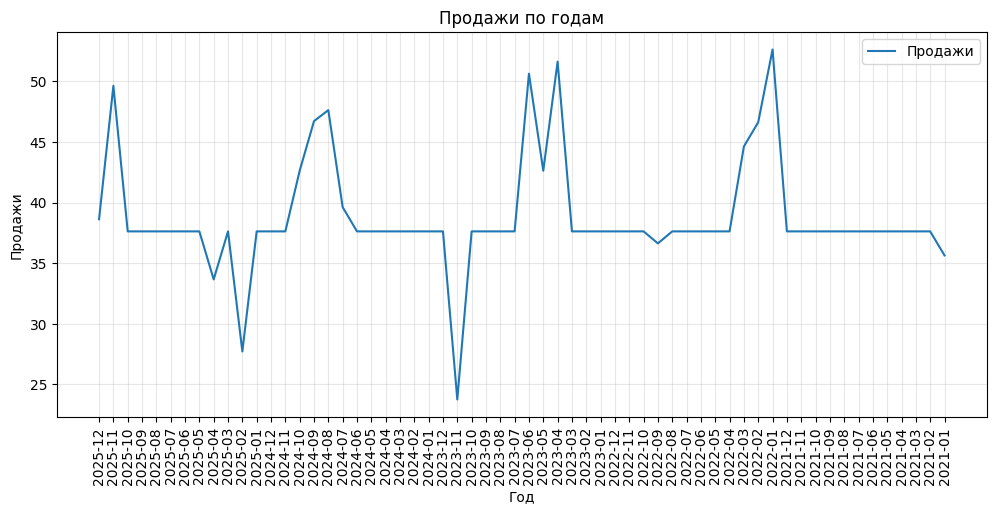

In [45]:
plt.figure(figsize=(12, 5))
plt.plot(data["InvoiceYear"], data["Total"], label="Продажи")
plt.xticks(rotation="vertical")
plt.xlabel("Год")
plt.ylabel("Продажи")
plt.title("Продажи по годам")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()